In [24]:
%load_ext mypy_ipython

The mypy_ipython extension is already loaded. To reload it, use:
  %reload_ext mypy_ipython


In [25]:
import os
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, BaseMessage
from collections.abc import Sequence
from typing import Literal
from dotenv import load_dotenv
load_dotenv()

True

In [26]:
api_key = os.getenv("API_KEY")

In [27]:
chat = ChatOllama(
    model="gpt-oss:120b",
    temperature=0.7,
    base_url="https://ollama.com",
    client_kwargs={
        "headers": {
            "Authorization": f"Bearer {api_key}"
        }
    }
)

In [28]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [29]:
def ask_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_question:")
    
    print("What is your question?")
    
    return State(messages = [HumanMessage(input())])

In [30]:
ask_question(State(messages = []))


-------> ENTERING ask_question:
What is your question?


{'messages': [HumanMessage(content='What is ai', additional_kwargs={}, response_metadata={})]}

In [31]:
def chatbot(state: State) -> State:
    
    print(f"\n-------> ENTERING chatbot:")
    
    response = chat.invoke(state["messages"])
    response.pretty_print()
    
    return State(messages = [response])

In [32]:
def ask_another_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_another_question:")
    
    print("Would you like to ask one more question (yes/no)?")
    
    return State(messages = [HumanMessage(input())])

In [33]:
ask_another_question(State(messages = []))


-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?


{'messages': [HumanMessage(content='what is ML', additional_kwargs={}, response_metadata={})]}

In [34]:
def routing_function(state: State) -> Literal["ask_question", "__end__"]:
    
    if state["messages"][0].content == "yes":
        return "ask_question"
    else:
        return "__end__"

In [35]:
graph = StateGraph(State)

In [36]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", 
                            path = routing_function)

In [37]:
graph_compiled = graph.compile()

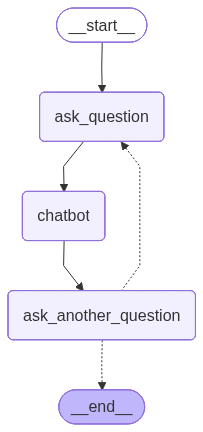

In [38]:
graph_compiled

In [39]:
print(graph_compiled.get_graph().draw_ascii())

          +-----------+       
          | __start__ |       
          +-----------+       
                 *            
                 *            
                 *            
         +--------------+     
         | ask_question |     
         +--------------+     
          ***         ..      
         *              ..    
       **                 ..  
+---------+                 . 
| chatbot |               ..  
+---------+             ..    
          ***         ..      
             *      ..        
              **   .          
     +----------------------+ 
     | ask_another_question | 
     +----------------------+ 
                 .            
                 .            
                 .            
            +---------+       
            | __end__ |       
            +---------+       


In [40]:
graph_compiled.invoke(State(messages = []))


-------> ENTERING ask_question:
What is your question?

-------> ENTERING chatbot:
================================== Ai Message ==================================

Artificial intelligence (AI) is the field of computer science that creates systems capable of performing tasks that normally require human intelligence. These tasks include learning from data, recognizing patterns, understanding language, making decisions, and adapting to new situations. AI combines techniques such as machine learning, deep learning, natural‑language processing, computer vision, and robotics. By modeling cognitive processes with algorithms and massive datasets, AI enables computers to predict outcomes, automate processes, and interact with users in increasingly human‑like ways. Its applications span healthcare, finance, transportation, entertainment, and many other domains, reshaping how we work and live across the globe today, rapidly.

-------> ENTERING ask_another_question:
Would you like to ask one mor

{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}